In [10]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [11]:
np.random.seed(42)
n_samples = 1000

mean0 = np.array([0, 0, 0])
cov0 = np.eye(3) * 1.2
X0 = np.random.multivariate_normal(mean0, cov0, n_samples // 2)
y0 = np.zeros(n_samples // 2)

mean1 = np.array([3, 2, 1])
cov1 = np.eye(3) * 1.2
X1 = np.random.multivariate_normal(mean1, cov1, n_samples // 2)
y1 = np.ones(n_samples // 2)

X = np.vstack([X0, X1])
y = np.hstack([y0, y1])

In [12]:
def pca_from_scratch(X, n_components):
    X_centered = X - np.mean(X, axis=0)
    cov_matrix = np.cov(X_centered, rowvar=False)
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    W = eigenvectors[:, :n_components]
    X_pca = X_centered @ W
    return X_pca, eigenvalues, eigenvectors, X_centered

X_pca_2d, evals, _, _ = pca_from_scratch(X, n_components=2)
X_pca_1d, _, _, _ = pca_from_scratch(X, n_components=1)

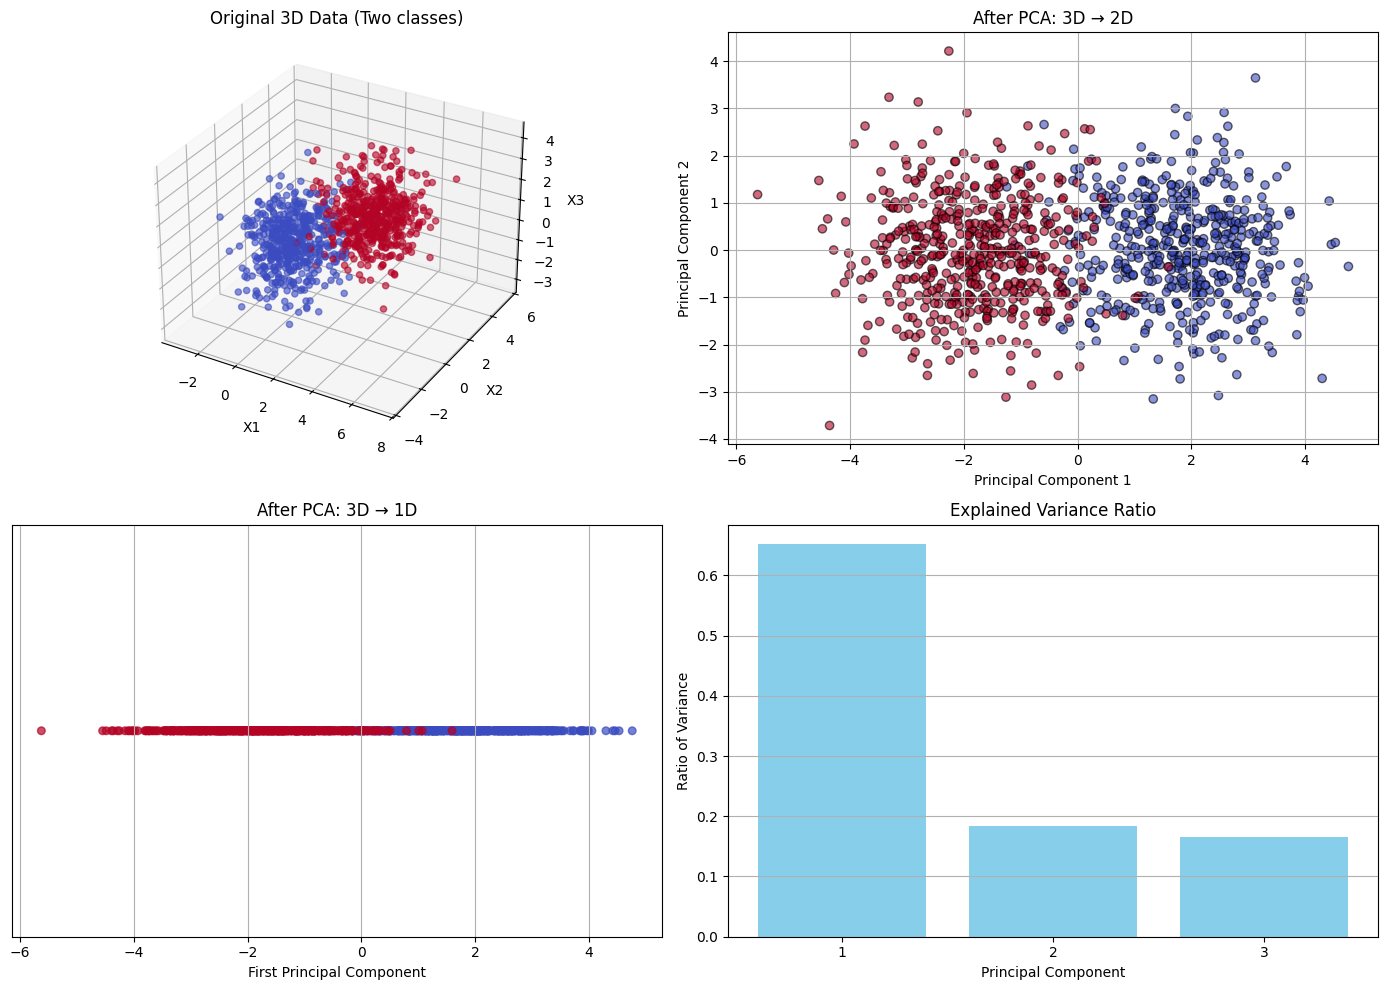

Variance explained by PC1: 65.12%
Variance explained by PC1+PC2: 83.43%


In [13]:

fig = plt.figure(figsize=(14, 10))

ax1 = fig.add_subplot(221, projection='3d')
ax1.scatter(X[:, 0], X[:, 1], X[:, 2], c=y, cmap='coolwarm', alpha=0.6, s=20)
ax1.set_title('Original 3D Data (Two classes)')
ax1.set_xlabel('X1')
ax1.set_ylabel('X2')
ax1.set_zlabel('X3')

ax2 = fig.add_subplot(222)
ax2.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y, cmap='coolwarm', alpha=0.6, edgecolors='k')
ax2.set_title('After PCA: 3D → 2D')
ax2.set_xlabel('Principal Component 1')
ax2.set_ylabel('Principal Component 2')
ax2.grid(True)

ax3 = fig.add_subplot(223)
x_1d = X_pca_1d.flatten()
y_1d = np.zeros_like(x_1d)
scatter = ax3.scatter(x_1d, y_1d, c=y, cmap='coolwarm', alpha=0.7, s=30)
ax3.set_title('After PCA: 3D → 1D')
ax3.set_xlabel('First Principal Component')
ax3.set_yticks([])
ax3.grid(True, axis='x')

explained_var_ratio = evals / np.sum(evals)
ax4 = fig.add_subplot(224)
ax4.bar(range(1, len(evals)+1), explained_var_ratio, color='skyblue')
ax4.set_title('Explained Variance Ratio')
ax4.set_xlabel('Principal Component')
ax4.set_ylabel('Ratio of Variance')
ax4.set_xticks(range(1, len(evals)+1))
ax4.grid(axis='y')

plt.tight_layout()
plt.show()

print(f"Variance explained by PC1: {explained_var_ratio[0]:.2%}")
print(f"Variance explained by PC1+PC2: {explained_var_ratio[:2].sum():.2%}")

In [14]:
print(f"Variance explained by PC1: {explained_var_ratio[0]:.2%}")
print(f"Variance explained by PC1+PC2: {explained_var_ratio[:2].sum():.2%}")

Variance explained by PC1: 65.12%
Variance explained by PC1+PC2: 83.43%
